# TP 3 : IA & Santé - Profilage (Clustering) 🧬
(CORRECTION DÉTAILLÉE)

**Objectif :** Sans utiliser le diagnostic connu, retrouver des groupes de patients.

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
data = load_breast_cancer(as_frame=True); X = data.data; df = data.frame; X_scaled = StandardScaler().fit_transform(X)

## 1. Méthode du Coude (Elbow Method)

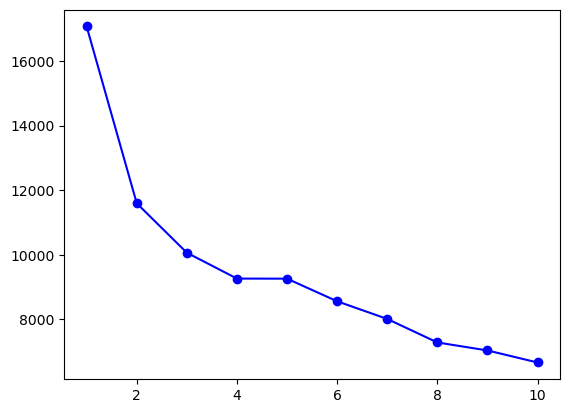

In [3]:
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    inertias.append(km.inertia_)
plt.plot(K_range, inertias, 'bo-')
plt.show()

## 2. Dendrogramme (Clustering Hiérarchique)

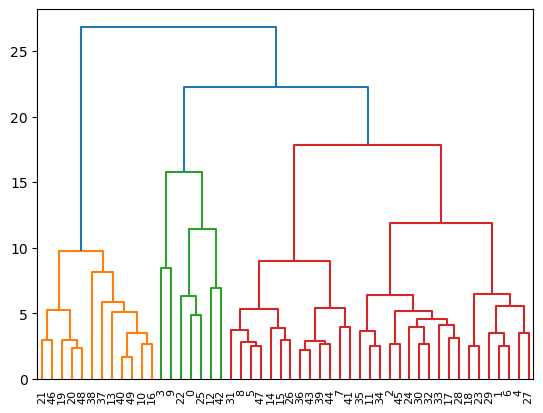

In [4]:
Z = linkage(X_scaled[:50], method='ward') 
dendrogram(Z)
plt.show()

## 3. Interprétation : Qui sont ces profils ?

### A. Profilage des Clusters (Centroids)
Regardons la moyenne des variables pour chaque cluster trouvé. C'est comme la "Feature Importance" du non-supervisé : cela nous dit ce qui définit chaque groupe.

         mean radius  mean texture  mean concavity
Cluster                                           
0          17.600702     21.403989        0.179992
1          12.413378     18.246352        0.043801


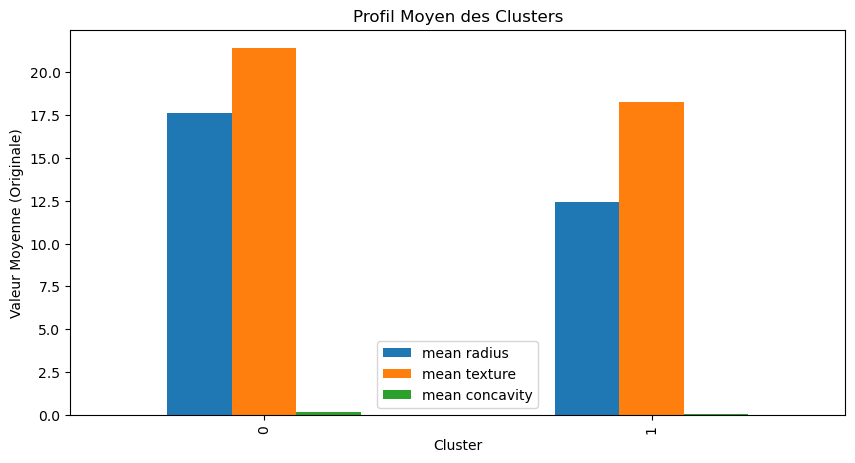

In [5]:
# On récupère les labels trouvés par K-Means (pour K=2)
km = KMeans(n_clusters=2, random_state=42).fit(X_scaled)
labels = km.labels_

# Ajoutons ça au DataFrame original pour analyser
df['Cluster'] = labels
means = df.groupby('Cluster')[['mean radius', 'mean texture', 'mean concavity']].mean()
print(means)

# Visualisons
means.plot(kind='bar', figsize=(10, 5))
plt.title("Profil Moyen des Clusters")
plt.ylabel("Valeur Moyenne (Originale)")
plt.show()

### 💡 Analyse
*   Le **Cluster 0** a des valeurs très élevées (Rayon, Concavité...) -> Il correspond aux tumeurs **Malignes** (Gros et irrégulier).
*   Le **Cluster 1** a des valeurs faibles -> Il correspond aux tumeurs **Bénignes** (Petit et régulier).
L'algorithme a "redécouvert" le cancer sans qu'on lui dise quoi chercher !

### B. Validation avec la Vérité (Ground Truth)
Comme c'est un TP, nous avons en fait les vraies étiquettes (`y`). Vérifions si le clustering a vu juste.

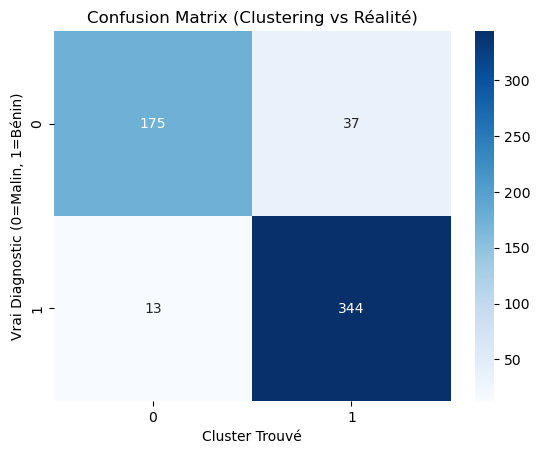

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Attention : les labels (0/1) du K-Means sont arbitraires.
# Si Cluster 0 = Malin et y=0 = Malin, ça colle. Sinon faut inverser.
# Vérifions :
cm = confusion_matrix(load_breast_cancer().target, labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Cluster Trouvé")
plt.ylabel("Vrai Diagnostic (0=Malin, 1=Bénin)")
plt.title("Confusion Matrix (Clustering vs Réalité)")
plt.show()